# **Projet : Système de recommandation de produits (Video Games)**

Ce projet présente la conception et l’implémentation d’un système de recommandation de produits basé sur le dataset Amazon Video Games.

L’objectif principal est de proposer des recommandations personnalisées aux utilisateurs en exploitant leurs interactions avec les produits (notes et avis).

Le projet est structuré en plusieurs étapes :

* Analyse et prétraitement des données
* Implémentation de méthodes classiques de recommandation (filtrage collaboratif, similarité cosinus)
* Développement d’un modèle basé sur le Deep Learning utilisant des embeddings

Les technologies utilisées incluent Python, TensorFlow et Keras.

Ce repository contient l’ensemble du code nécessaire pour reproduire les résultats, depuis le traitement des données jusqu’à la génération des recommandations.


# **1. Étude des données**

In [203]:
import pandas as pd
import numpy as np

In [204]:
import json
data = []
with open('Video_Games.json', 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping malformed JSON line: {line.strip()} - Error: {e}")
df = pd.DataFrame(data)
df.head()

Skipping malformed JSON line: {"overall": 5.0, "vote": "3", "verified": false, "reviewTime": "08 11, 2006", "reviewerID": "A16BG7VZXUUQGS", "asin": "B000F3AADE", "reviewerName": "rusty (zombie-slayer)", "reviewText": "Ok i agree that the saving system is a bit stupid and hard to get by but once you get aside that its pretty fun. The zombies are cool and there are quite a few different models so you sometimes see the same looking zombie every now and then but what gets me past that is the amount of zombies in the game (54,593 total. and they respawn so your never on short supply) and the situations you can get yourself into.\n\nthe story is not oscar-worthy but still good enough for any die-hard zombie fan. you can drive some vehicles (dont drive the motorcyle cause that can get you killed) and other things like a cart, but since that once you get a some movable object like a cart it reverses the controls. but i sometimes feel is really - Error: Unterminated string starting at: line 1 c

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image
0,1.0,True,"06 9, 2014",A21ROB4YDOZA5P,0439381673,Mary M. Clark,I used to play this game years ago and loved i...,Did not like this,1402272000,NaN,NaN,NaN
1,3.0,True,"05 10, 2014",A3TNZ2Q5E7HTHD,0439381673,Sarabatya,The game itself worked great but the story lin...,Almost Perfect,1399680000,NaN,NaN,NaN
2,4.0,True,"02 7, 2014",A1OKRM3QFEATQO,0439381673,Amazon Customer,I had to learn the hard way after ordering thi...,DOES NOT WORK WITH MAC OS unless it is 10.3 or...,1391731200,15,NaN,NaN
3,1.0,True,"02 7, 2014",A2XO1JFCNEYV3T,0439381673,ColoradoPartyof5,The product description should state this clea...,does not work on Mac OSX,1391731200,11,NaN,NaN
4,4.0,True,"01 16, 2014",A19WLPIRHD15TH,0439381673,Karen Robinson,I would recommend this learning game for anyon...,Roughing it,1389830400,NaN,NaN,NaN


In [205]:
df.shape

(289580, 12)

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289580 entries, 0 to 289579
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   overall         289580 non-null  float64
 1   verified        289580 non-null  bool   
 2   reviewTime      289580 non-null  object 
 3   reviewerID      289580 non-null  object 
 4   asin            289580 non-null  object 
 5   reviewerName    289569 non-null  object 
 6   reviewText      289512 non-null  object 
 7   summary         289526 non-null  object 
 8   unixReviewTime  289580 non-null  int64  
 9   vote            93111 non-null   object 
 10  style           117595 non-null  object 
 11  image           925 non-null     object 
dtypes: bool(1), float64(1), int64(1), object(9)
memory usage: 24.6+ MB


**1. Analyse descriptive des données**

**1.1. Analyse des notes**

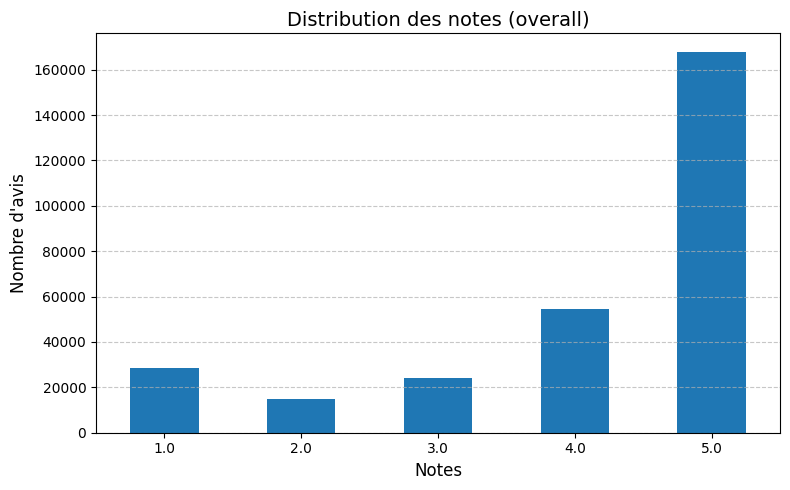

In [207]:
import matplotlib.pyplot as plt

# Comptage des valeurs triées
counts = df['overall'].value_counts().sort_index()

# Création du graphique
plt.figure(figsize=(8,5))
counts.plot(kind='bar')

# Personnalisation
plt.title("Distribution des notes (overall)", fontsize=14)
plt.xlabel("Notes", fontsize=12)
plt.ylabel("Nombre d'avis", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [208]:
df['overall'].mean()

np.float64(4.097997099247186)

In [209]:
df['overall'].median()

5.0

**1.2. Analyse des utilisateurs**

In [210]:
## Nombre d'utilisateurs uniques
nbr_utilisateur=len(df['reviewerID'].unique())
print('le nombre des utilisateurs est :',nbr_utilisateur)

le nombre des utilisateurs est : 200114


In [211]:
# Nombre d'avis par utilisateur
reviews_per_user = df.groupby('reviewerID').size()

# Moyenne
avg_reviews = reviews_per_user.mean()
print("Nombre moyen d'avis par utilisateur :", avg_reviews)

Nombre moyen d'avis par utilisateur : 1.4470751671547217


**1.3. Analyse des utilisateurs**

In [212]:
## Nombre de produit uniques
nbr_produit=len(df['asin'].unique())
print('le nombre des produits est :',nbr_produit)

le nombre des produits est : 6502


In [213]:
# Nombre d'avis par produit
reviews_per_product = df['asin'].value_counts()

# Top 10 produits les plus commentés
top_products = reviews_per_product.head(10)
print(top_products)

asin
B000B9RI14    3335
B0009VXBAQ    3157
B00009OY9U    2004
B000087H7T    1599
B000066TS5    1395
B000ERVMI8    1389
B00005TNI6    1372
B00005NZ1G    1331
B0000C7GHG    1226
B00000JRSB    1140
Name: count, dtype: int64


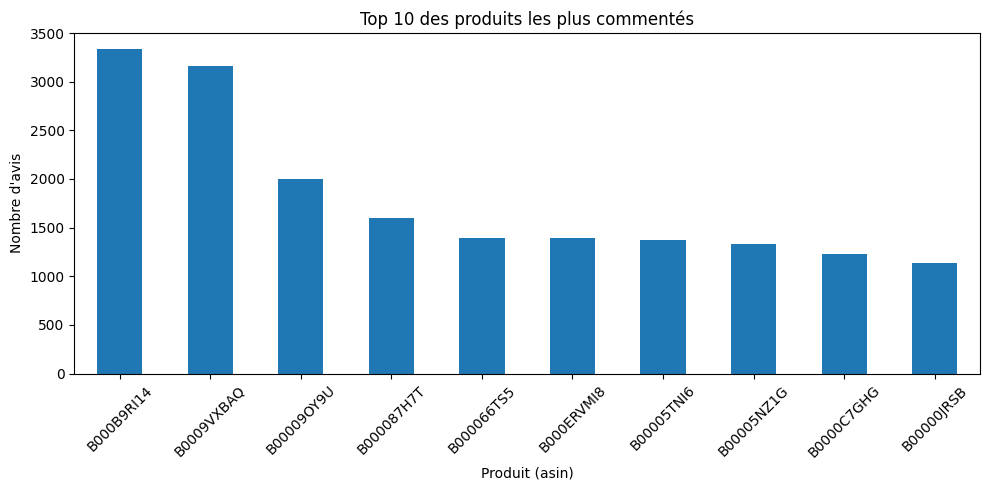

In [214]:


plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title("Top 10 des produits les plus commentés")
plt.xlabel("Produit (asin)")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**2. Nettoyage des données**

In [215]:
df=df.drop(columns='image')

In [216]:
#Remplacer les valeurs manquantes (texte)
df['reviewText'] =df['reviewText'].fillna('Aucun commentaire')
df['summary'] = df['summary'].fillna('Aucun résumer')
df['reviewerName'] = df['reviewerName'].fillna('Utilisateur inconnu')

In [217]:
# Remplacer NaN par 0
df['vote'] = df['vote'].fillna(0)

# Convertir en numérique
df['vote'] = df['vote'].astype(str).str.replace(',', '').astype(int)

In [218]:
df = df.drop(columns=['style'])

In [219]:
# Convertir en numérique
df['overall'] = df['overall'].astype(int)

In [220]:
# Nombre de doublons exacts
duplicates = df.duplicated().sum()
print("Nombre de lignes dupliquées :", duplicates)

Nombre de lignes dupliquées : 104


In [221]:
df = df.drop_duplicates()

In [222]:
import re
import string
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isnull(text):
        return ""

    # minuscule
    text = text.lower()

    # supprimer urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # supprimer ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # supprimer chiffres
    text = re.sub(r'\d+', '', text)

    # supprimer emojis / caractères spéciaux
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # tokenisation
    words = text.split()

    # suppression stopwords + lemmatisation
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [223]:
df['clean_review'] = df['reviewText'].apply(clean_text)

**3. Préparation des données pour le modèle**

Dans cette étape, les données brutes sont transformées afin d’être exploitables par un système de recommandation. L’objectif principal est de construire une matrice utilisateur-produit représentant les interactions entre les utilisateurs et les produits.

In [224]:
df_model=df[['reviewerID','asin','overall']]
df_model.columns=['user_id', 'product_id', 'rating']

In [225]:
df_model.head()

,user_id,product_id,rating
0,A21ROB4YDOZA5P,0439381673,1
1,A3TNZ2Q5E7HTHD,0439381673,3
2,A1OKRM3QFEATQO,0439381673,4
3,A2XO1JFCNEYV3T,0439381673,1
4,A19WLPIRHD15TH,0439381673,4


In [226]:
user_counts = df_model['user_id'].value_counts()
df_model = df_model[df_model['user_id'].isin(user_counts[user_counts > 3].index)]


product_counts = df_model['product_id'].value_counts()
df_model = df_model[df_model['product_id'].isin(product_counts[product_counts > 3].index)]

In [227]:
matrix = df_model.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating'
)

In [228]:
matrix.head()

product_id,0700026657,0700099867,0804161380,9629971372,9867299434,9882106463,9882155456,B000003SQQ,B000006OVE,B000006OVF,...,B000F1UK3Q,B000F1UK4U,B000F1WDHW,B000F1WGCY,B000F1YGMM,B000F1YHW6,B000F1YI3E,B000F2DE8S,B000F3AACA,B000F3AADE
user_id,,,,,,,,,,,,,,,,,,,,,
A0759107CA9MPWVRF6VN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A100JCBNALJFAW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
A100NE7N89DVC0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A100O5QLORBZRO,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A100Y9BI0I69B8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [229]:
matrix.fillna(0, inplace=True)

In [230]:
matrix.head()

product_id,0700026657,0700099867,0804161380,9629971372,9867299434,9882106463,9882155456,B000003SQQ,B000006OVE,B000006OVF,...,B000F1UK3Q,B000F1UK4U,B000F1WDHW,B000F1WGCY,B000F1YGMM,B000F1YHW6,B000F1YI3E,B000F2DE8S,B000F3AACA,B000F3AADE
user_id,,,,,,,,,,,,,,,,,,,,,
A0759107CA9MPWVRF6VN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100JCBNALJFAW,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
A100NE7N89DVC0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100O5QLORBZRO,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100Y9BI0I69B8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [231]:
matrix.describe()

product_id,0700026657,0700099867,0804161380,9629971372,9867299434,9882106463,9882155456,B000003SQQ,B000006OVE,B000006OVF,...,B000F1UK3Q,B000F1UK4U,B000F1WDHW,B000F1WGCY,B000F1YGMM,B000F1YHW6,B000F1YI3E,B000F2DE8S,B000F3AACA,B000F3AADE
count,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,...,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000,8229.000000
mean,0.002917,0.001215,0.003524,0.021874,0.004496,0.002917,0.005712,0.001458,0.010208,0.002187,...,0.004618,0.001944,0.002795,0.003038,0.005104,0.006319,0.002430,0.022117,0.013246,0.035363
std,0.114531,0.058323,0.130859,0.321802,0.143246,0.114531,0.160794,0.071431,0.214095,0.099806,...,0.122675,0.096088,0.115064,0.112925,0.139355,0.174196,0.088161,0.307493,0.247387,0.377527
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# **2. Méthodes de recommandation**

**1. Filtrage collaboratif**

Le filtrage collaboratif consiste à recommander des produits à un utilisateur en se basant sur les préférences d’autres utilisateurs ayant des comportements similaires.

il ya deux types de filtrage colaboratif

*  User-Based (utilisateurs similaires)
*  Item-Based (produits similaires)

**2. Recommandation par similarité**

In [232]:
from sklearn.metrics.pairwise import cosine_similarity


# Similarité entre produits (item-based)
item_similarity = cosine_similarity(matrix.T)

# Transformer en DataFrame
item_sim_df = pd.DataFrame(
    item_similarity,
    index=matrix.columns,
    columns=matrix.columns
)

In [233]:
#Trouver des produits similaires
def get_similar_products(product_id, n=5):
    similar_products = item_sim_df[product_id].sort_values(ascending=False)
    return similar_products[1:n+1]

**3. Recommander pour un utilisateur**

In [234]:
def recommend_products(user_id, n=5):
    user_ratings = matrix.loc[user_id]

    # Score = similarité × ratings
    scores = item_sim_df.dot(user_ratings)

    # Trier
    scores = scores.sort_values(ascending=False)

    return scores.head(n)

In [235]:
#application

user_similarity = cosine_similarity(matrix)

user_sim_df = pd.DataFrame(
    user_similarity,
    index=matrix.index,
    columns=matrix.index
)

In [236]:
user_sim_df

user_id,A0759107CA9MPWVRF6VN,A100JCBNALJFAW,A100NE7N89DVC0,A100O5QLORBZRO,A100Y9BI0I69B8,A101R7OO4IRDTH,A101S27XGJ8C66,A102GA81P1MWWZ,A102KAIWB6NU7A,A103AZLY78GMZW,...,AZW4K59K4QWZ8,AZWKRO5BBSBEB,AZXHK8IO25FL6,AZYCXCDP9CSM1,AZYU8M791SIFC,AZZ1KF8RAO1BR,AZZ3GFL1HTBLY,AZZAX6DNC2VBP,AZZD3NL4WSO9I,AZZLET9K4OLHP
user_id,,,,,,,,,,,,,,,,,,,,,
A0759107CA9MPWVRF6VN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
A100JCBNALJFAW,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
A100NE7N89DVC0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
A100O5QLORBZRO,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
A100Y9BI0I69B8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.179284,0.000000,...,0.0,0.0,0.0,0.305424,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AZZ1KF8RAO1BR,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.140028,1.0,0.0,0.0,0.0,0.0
AZZ3GFL1HTBLY,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.293798,0.0,1.0,0.0,0.0,0.0
AZZAX6DNC2VBP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.233285,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0


In [237]:
# Produits similaires
#get_similar_products(product_id='0700099867')

In [238]:
# Recommandation utilisateur
#recommend_products(user_id='AZZLET9K4OLHP')

# **3. Modèle d’apprentissage profond**

Le **modèle d’Embedding** est une notion centrale en apprentissage profond, surtout dans les systèmes de recommandation

Un embedding est une représentation numérique dense (vecteur) d’un objet (mot, utilisateur, produit, etc.) dans un espace de dimension réduite.

👉 Au lieu de représenter un élément par un vecteur long et creux (comme le one-hot encoding), on le représente par un vecteur compact qui capture du sens.

**1. Préparation des données**

In [239]:

# Encodage des IDs (obligatoire pour embeddings)
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
product_encoder = LabelEncoder()

df_model['user_id'] = user_encoder.fit_transform(df_model['user_id'])
df_model['product_id'] = product_encoder.fit_transform(df_model['product_id'])

# Nombre total
num_users = df_model['user_id'].nunique()
num_products = df_model['product_id'].nunique()

print(num_users, num_products)

8229 3294


**2. Séparation train / test**

In [240]:
from sklearn.model_selection import train_test_split
train , test = train_test_split(df_model, test_size=0.2, random_state=42)

In [280]:
#normalisation

train['rating'] = (train['rating'] - 1) / 4
test['rating'] = (test['rating'] - 1) / 4

**3. Construction du modèle (Keras)**

In [335]:
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

embedding_size = 32   # ↓ plus petit = mieux généralisation

user_input = Input(shape=(1,))
product_input = Input(shape=(1,))

# embeddings avec régularisation
user_embedding = Embedding(
    num_users, embedding_size,
    embeddings_regularizer=l2(1e-5)
)(user_input)

product_embedding = Embedding(
    num_products, embedding_size,
    embeddings_regularizer=l2(1e-5)
)(product_input)

user_vec = Flatten()(user_embedding)
product_vec = Flatten()(product_embedding)

# interaction
dot = Dot(axes=1)([user_vec, product_vec])

# biais
user_bias = Flatten()(Embedding(num_users, 1)(user_input))
product_bias = Flatten()(Embedding(num_products, 1)(product_input))

# fusion
x = Concatenate()([dot, user_bias, product_bias])

# 🔥 réseau SIMPLE (important)
x = Dense(32, activation='relu', kernel_regularizer=l2(1e-3))(x)
x = Dropout(0.4)(x)

x = Dense(16, activation='relu', kernel_regularizer=l2(1e-3))(x)


output = Dense(1, activation='sigmoid')(x) # Removed * 5

model = Model([user_input, product_input], output)





**4. Compilation**

In [326]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_25      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_44        │ (None, 1, 32)     │    263,328 │ input_layer_24[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_45        │ (None, 1, 32)     │    105,408 │ input_layer_25[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_62          │ (None, 32)        │          0 │ embedding_44[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_63          │ (None, 32)        │          0 │ embedding_45[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_46        │ (None, 1, 1)      │      8,229 │ input_layer_24[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_47        │ (None, 1, 1)      │      3,294 │ input_layer_25[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_12 (Dot)        │ (None, 1)         │          0 │ flatten_62[0][0], │
│                     │                   │            │ flatten_63[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_64          │ (None, 1)         │          0 │ embedding_46[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_65          │ (None, 1)         │          0 │ embedding_47[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 3)         │          0 │ dot_12[0][0],     │
│ (Concatenate)       │                   │            │ flatten_64[0][0], │
│                     │                   │            │ flatten_65[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 32)        │        128 │ concatenate_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 32)        │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 16)        │        528 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 1)         │         17 │ dense_47[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1)         │          0 │ dense_48[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 380,932 (1.45 MB)

 Trainable params: 380,932 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

In [327]:
#Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

**5. Entraînement**

In [328]:
history = model.fit(
    [train['user_id'], train['product_id']],
    train['rating'],
    epochs=20,
    batch_size=32,
    validation_data=(
        [test['user_id'], test['product_id']],
        test['rating']
    ),
    callbacks=[early_stop]
)

Epoch 1/20
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.4777 - mae: 0.4093 - val_loss: 0.1629 - val_mae: 0.2558
Epoch 2/20
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.1546 - mae: 0.2531 - val_loss: 0.1533 - val_mae: 0.2546
Epoch 3/20
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.1465 - mae: 0.2512 - val_loss: 0.1478 - val_mae: 0.2542
Epoch 4/20
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 0.1424 - mae: 0.2505 - val_loss: 0.1455 - val_mae: 0.2539
Epoch 5/20
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.1413 - mae: 0.2501 - val_loss: 0.1451 - val_mae: 0.2537
Epoch 6/20
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.1411 - mae: 0.2500 - val_loss: 0.1451 - val_mae: 0.2537
Epoch 7/20
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.1411 - mae: 0.2500 - val_loss: 0.1451 - val_mae: 0.2536
Epoch 8/20
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.1411 - mae: 0.2500 - val_loss: 0.1451 - val_mae: 0.2536
Epoch 9/20
1535/1535 ━━━━━━

**6. Évaluation**

In [329]:
model.evaluate(
    [test['user_id'], test['product_id']],
    test['rating']
)

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1451 - mae: 0.2536


[0.14507560431957245, 0.2536412179470062]

**7. Prédiction (Recommandation)**

In [330]:
import numpy as np

user_id = 10
product_id = 20
pred=model.predict([np.array([user_id]), np.array([product_id])])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
[[3.7640607e-08]]


**recommander Top N produits**

In [331]:
def recommend_products(user_id, top_n=5):
    product_ids = np.arange(num_products)
    user_ids = np.array([user_id] * num_products)

    predictions = model.predict([user_ids, product_ids]).flatten()

    top_products = product_ids[np.argsort(predictions)[-top_n:]]

    return product_encoder.inverse_transform(top_products)

In [295]:
!pip install fastapi uvicorn pyngrok

In [336]:
model.save("model.keras")

In [338]:
#Étape 3 : Créer API dans Colab
from fastapi import FastAPI
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

app = FastAPI()

# Charger modèle sans compilation
model = tf.keras.models.load_model("model.keras", compile=False)

# Recompiler le modèle manuellement
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

@app.get("/")
def home():
    return {"message": "API fonctionne sur Colab 🚀"}

In [341]:
#Étape 4 : Endpoint recommandation

@app.get("/recommend/{user_id}")
def recommend(user_id: int):
    product_ids = np.arange(num_products) # Use num_products for all products
    user_ids_array = np.array([user_id] * num_products)

    predictions = model.predict([user_ids_array, product_ids]).flatten()

    # Apply inverse scaling to get predictions back to 1-5 range
    predictions = (predictions * 4) + 1

    # Get top_n recommendations (e.g., 5)
    top_n = 5
    top_products_indices = np.argsort(predictions)[-top_n:]
    top_products_original_ids = product_encoder.inverse_transform(top_products_indices)

    return {
        "user_id": user_id,
        "recommendations": top_products_original_ids.tolist(),
        "predicted_ratings": predictions[top_products_indices].tolist()
    }

In [306]:
!pip install pyngrok

In [345]:
import gradio as gr
import numpy as np

def safe_encode(encoder, value):
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    else:
        return 0  # utilisateur inconnu ou produit inconnu


def predict(user_id_input, product_id_input):

    user_idx = safe_encode(user_encoder, user_id_input)
    product_idx = safe_encode(product_encoder, product_id_input)

    user_input_array = np.array([user_idx])
    product_input_array = np.array([product_idx])

    prediction = model.predict([user_input_array, product_input_array], verbose=0).flatten()[0]

    # si ton modèle est normalisé (0–1)
    predicted_rating = prediction * 4 + 1

    return float(predicted_rating)


gr.Interface(
    fn=predict,
    inputs=[
        gr.Textbox(label="User ID"),
        gr.Textbox(label="Product ID")
    ],
    outputs=gr.Number(label="Predicted Rating (1-5)")
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2c6751962ab22c864f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
